,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Média da coluna 'target': 152.13348416289594
Mediana da coluna 'target': 140.5
Moda da coluna 'target': 200.0
Variância da coluna 'target': 5929.884896910383
Desvio Padrão da coluna 'target': 77.00574586945044
Dimensões do dataset: (442, 11)

Tipos de dados:


,0
age,float64
sex,float64
bmi,float64
bp,float64
s1,float64
s2,float64
s3,float64
s4,float64
s5,float64
s6,float64



Valores ausentes:


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0



Duplicatas:
0

Estatísticas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


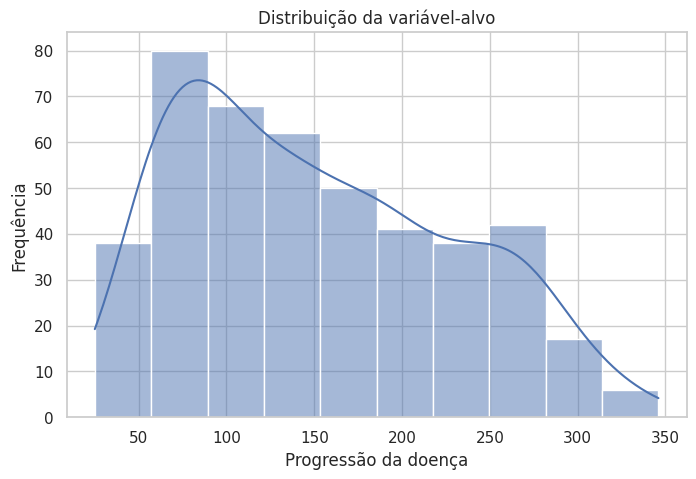

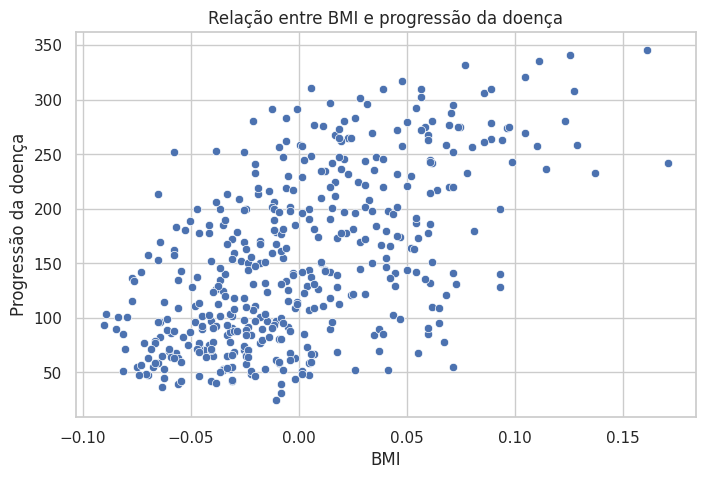

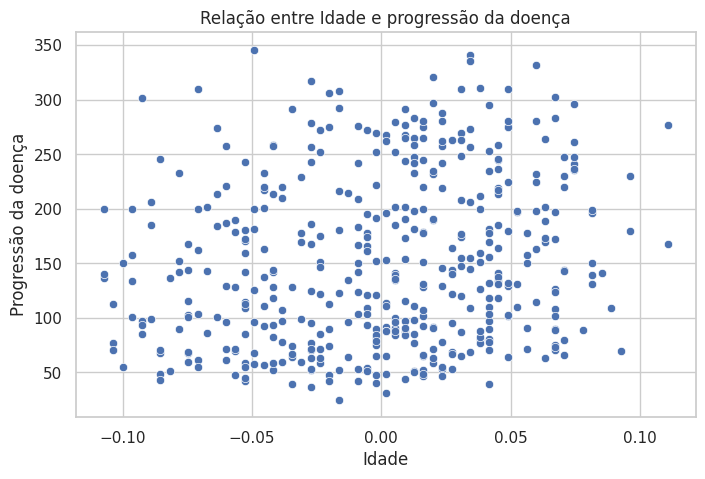

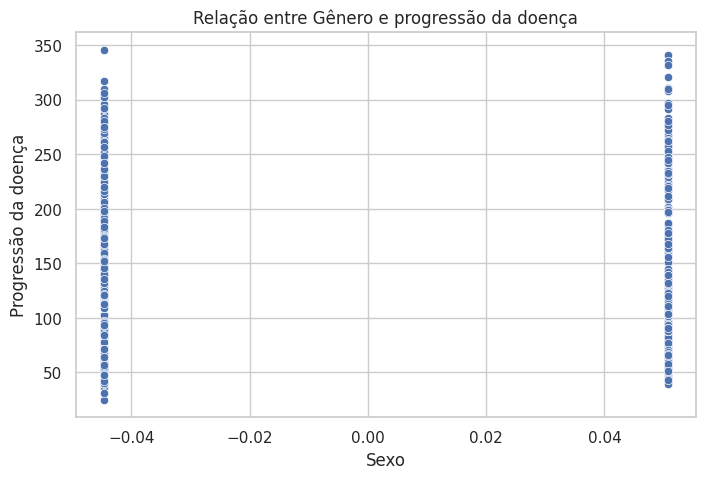

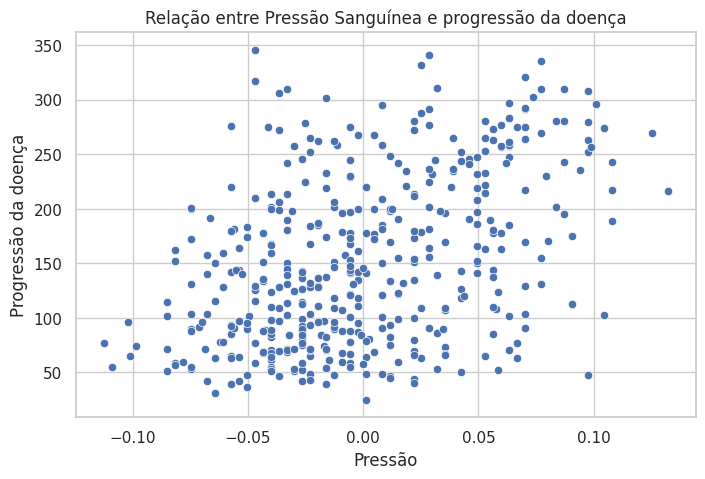

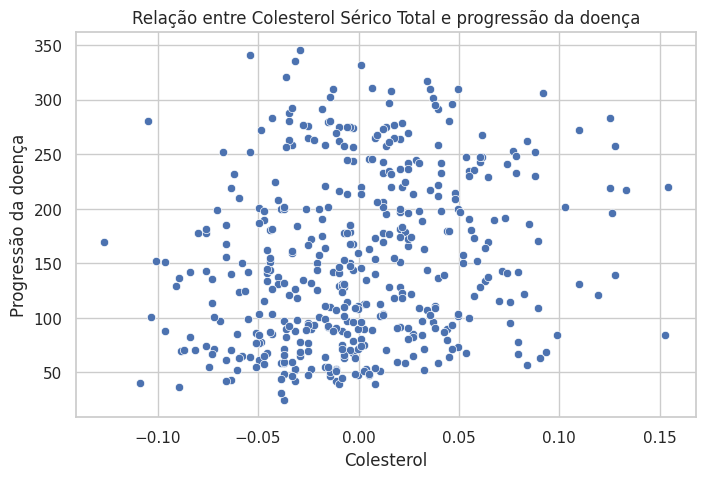

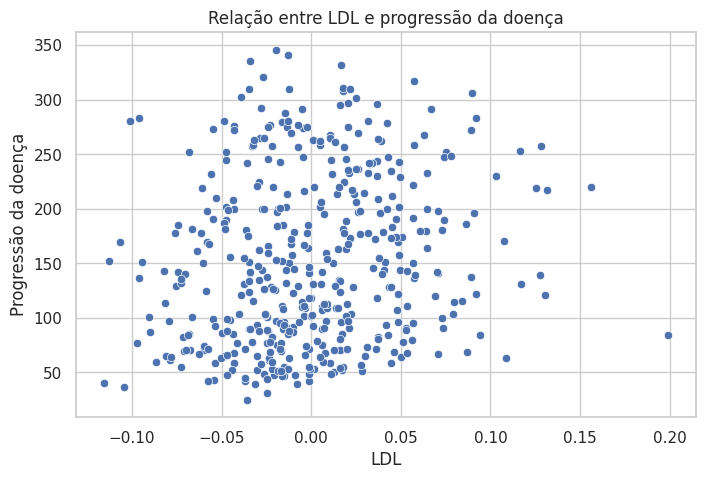

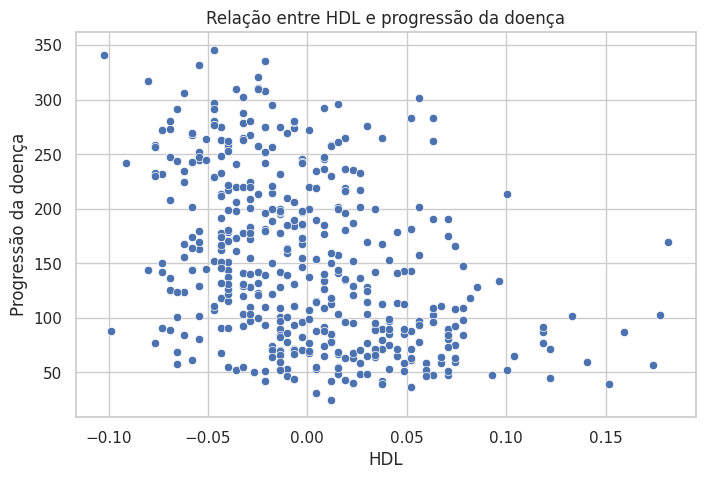

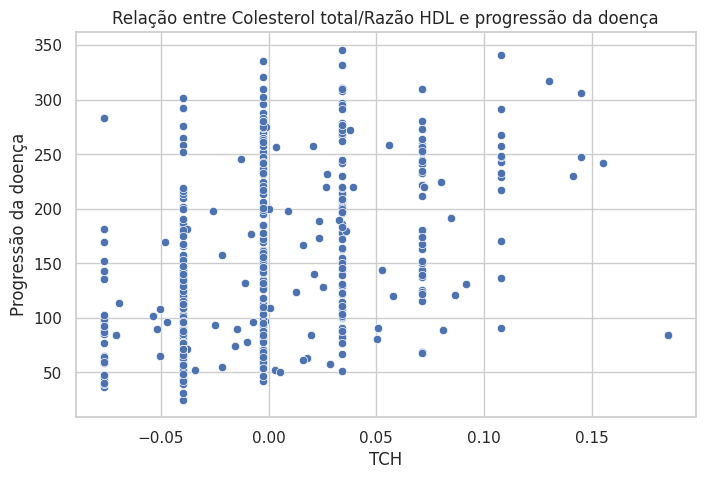

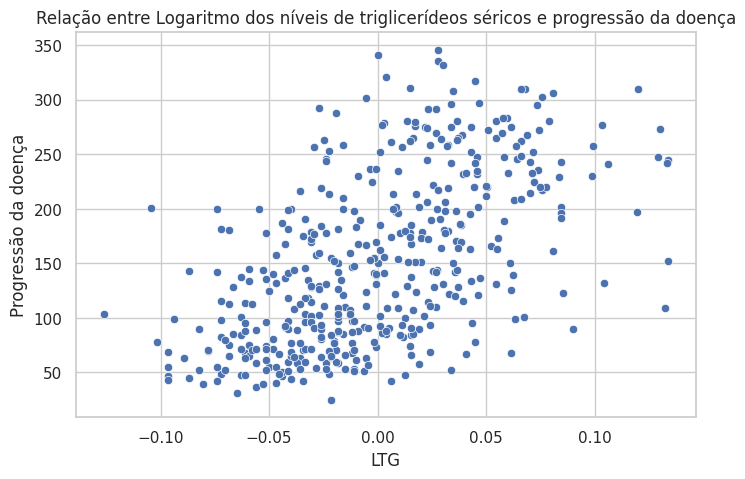

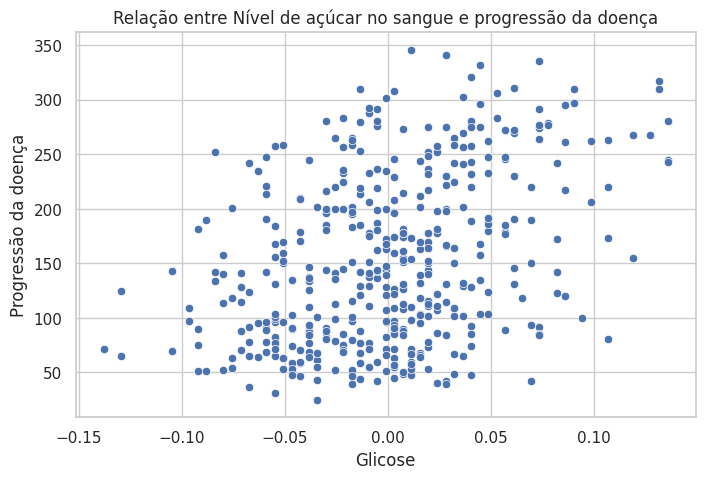

In [32]:
import math
from statistics import mode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.datasets import load_diabetes
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

sns.set_theme(style="whitegrid")

diabetes = load_diabetes(as_frame=True)

df = diabetes.frame.copy()

display(df.head())

def calcular_media(dados):
    return sum(dados) / len(dados)

def calcular_mediana(dados):
    dados_ordenados = sorted(dados)
    n = len(dados_ordenados)
    meio = n // 2
    if n % 2 == 0:
        return (dados_ordenados[meio - 1] + dados_ordenados[meio]) / 2
    else:
        return dados_ordenados[meio]

def calcular_moda(dados):
    contagem = {}
    for valor in dados:
        if valor in contagem:
            contagem[valor] += 1
        else:
            contagem[valor] = 1
    moda = max(contagem, key=contagem.get)
    return moda

def calcular_variancia(dados):
   media = calcular_media(dados)
   diferencas = [(x - media) ** 2 for x in dados]
   variancia = sum(diferencas) / len(dados)
   return variancia

def calcular_desvio_padrao(dados):
    variancia = calcular_variancia(dados)
    desvio_padrao = (variancia) ** 0.5
    return desvio_padrao

# As funções estatísticas personalizadas esperam uma série numérica (uma coluna).
# Para calcular a média, mediana, etc. de todas as colunas numéricas, você precisaria iterar sobre elas
# ou usar os métodos built-in do Pandas, como df.mean(), df.median(), etc.
# Por agora, vamos usar a coluna 'target' como exemplo.

print("==============================================================================================================================================================")

print("Média da coluna 'target':", calcular_media(df['target'])) # Fix: Passando uma coluna específica
print("Mediana da coluna 'target':", calcular_mediana(df['target']))
print("Moda da coluna 'target':", calcular_moda(df['target']))
print("Variância da coluna 'target':", calcular_variancia(df['target']))
print("Desvio Padrão da coluna 'target':", calcular_desvio_padrao(df['target']))

print("==============================================================================================================================================================")

print("Dimensões do dataset:", df.shape)

print("==============================================================================================================================================================")

print("\nTipos de dados:")
display(df.dtypes)

print("==============================================================================================================================================================")

print("\nValores ausentes:")
display(df.isna().sum())

print("==============================================================================================================================================================")

print("\nDuplicatas:")
print(df.duplicated().sum())

print("==============================================================================================================================================================")

print("\nEstatísticas:")
display(df.describe())

print("==============================================================================================================================================================")

print("Features:")
print(diabetes.feature_names)

print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.histplot(
    df["target"],
    kde=True
)

plt.title("Distribuição da variável-alvo")
plt.xlabel("Progressão da doença")
plt.ylabel("Frequência")

plt.show()

print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="target"
)

plt.title("Relação entre BMI e progressão da doença")
plt.xlabel("BMI")
plt.ylabel("Progressão da doença")

plt.show()


print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="target"
)

plt.title("Relação entre Idade e progressão da doença")
plt.xlabel("Idade")
plt.ylabel("Progressão da doença")

plt.show()


print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sex",
    y="target"
)

plt.title("Relação entre Gênero e progressão da doença")
plt.xlabel("Sexo")
plt.ylabel("Progressão da doença")

plt.show()

print("==============================================================================================================================================================")
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bp",
    y="target"
)

plt.title("Relação entre Pressão Sanguínea e progressão da doença")
plt.xlabel("Pressão")
plt.ylabel("Progressão da doença")

plt.show()

print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="s1",
    y="target"
)

plt.title("Relação entre Colesterol Sérico Total e progressão da doença")
plt.xlabel("Colesterol")
plt.ylabel("Progressão da doença")

plt.show()

print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="s2",
    y="target"
)

plt.title("Relação entre LDL e progressão da doença")
plt.xlabel("LDL")
plt.ylabel("Progressão da doença")

plt.show()


print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="s3",
    y="target"
)

plt.title("Relação entre HDL e progressão da doença")
plt.xlabel("HDL")
plt.ylabel("Progressão da doença")

plt.show()


print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="s4",
    y="target"
)

plt.title("Relação entre Colesterol total/Razão HDL e progressão da doença")
plt.xlabel("TCH")
plt.ylabel("Progressão da doença")

plt.show()


print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="s5",
    y="target"
)

plt.title("Relação entre Logaritmo dos níveis de triglicerídeos séricos e progressão da doença")
plt.xlabel("LTG")
plt.ylabel("Progressão da doença")

plt.show()


print("==============================================================================================================================================================")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="s6",
    y="target"
)

plt.title("Relação entre Nível de açúcar no sangue e progressão da doença")
plt.xlabel("Glicose")
plt.ylabel("Progressão da doença")

plt.show()


print("==============================================================================================================================================================")


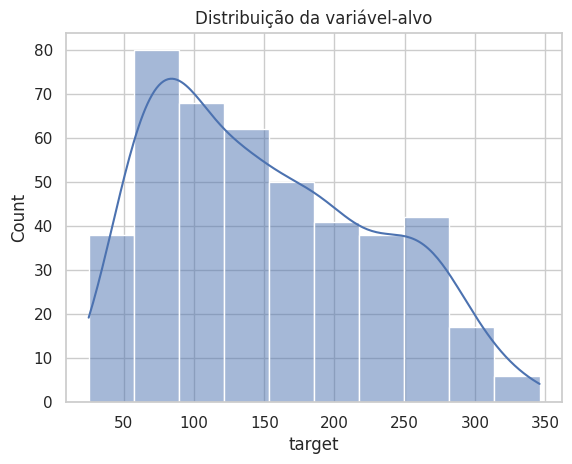

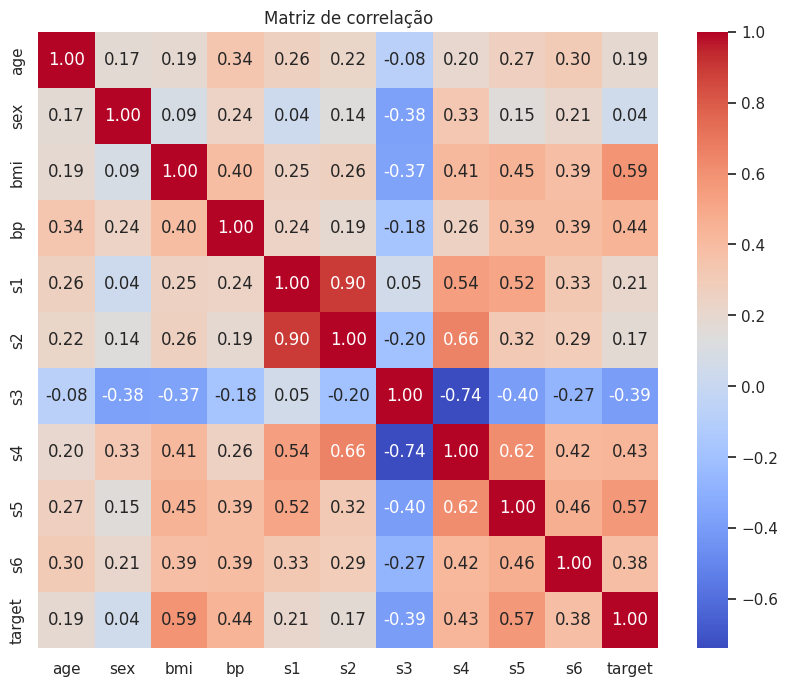

In [33]:
# Análise

sns.histplot(data=df, x="target", kde=True)
plt.title("Distribuição da variável-alvo")
plt.show()

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlação")
plt.show()

Dados de treinamento: (353, 10)
Dados de teste: (89, 10)
Resultados da validação cruzada
MAE médio: 44.7702
MSE médio: 3047.5143
RMSE médio: 55.0825
R² médio: 0.4814


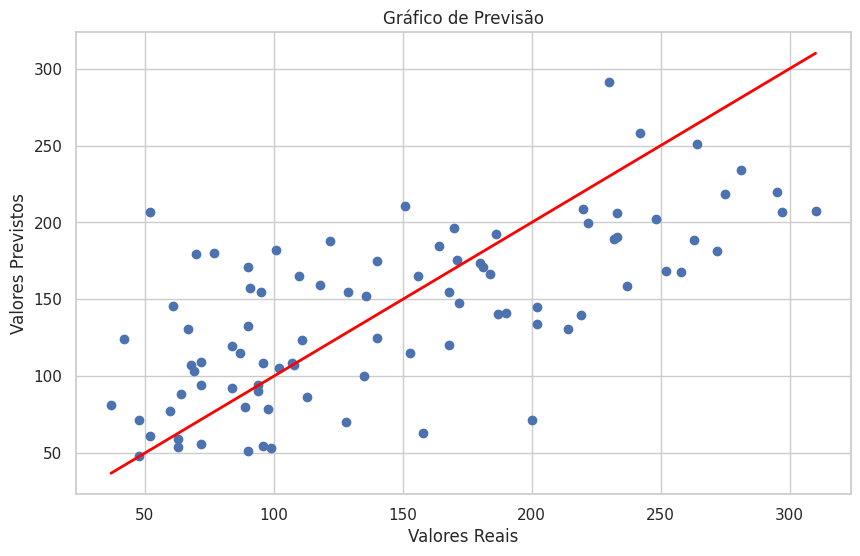

,Fold,MAE,MSE,RMSE,R²
0,1,39.120083,2547.955152,50.477274,0.587995
1,2,47.011387,3109.029201,55.758669,0.481762
2,3,48.420920,3445.216182,58.695964,0.375472
3,4,40.912990,2472.105336,49.720271,0.584764
4,5,45.587205,3273.793869,57.217077,0.561328
5,6,47.568537,3436.985778,58.625812,0.297125


In [34]:
X = df.drop(columns=["target"])
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dados de treinamento:", X_train.shape)
print("Dados de teste:", X_test.shape)


def separar_fold(X, y, inicio, fim):
    """Separa os dados em treino e teste para um fold."""

    X_fold_test = X.iloc[inicio:fim]
    y_fold_test = y.iloc[inicio:fim]

    X_fold_train = pd.concat([
        X.iloc[:inicio],
        X.iloc[fim:]
    ])

    y_fold_train = pd.concat([
        y.iloc[:inicio],
        y.iloc[fim:]
    ])

    return X_fold_train, X_fold_test, y_fold_train, y_fold_test


k = 6

tamanho_fold = len(X_train) // k

mae_por_fold = []
mse_por_fold = []
rmse_por_fold = []
r2_por_fold = []


for i in range(k):

    inicio = i * tamanho_fold

    if i == k - 1:
        fim = len(X_train)
    else:
        fim = inicio + tamanho_fold

    X_fold_train, X_fold_test, y_fold_train, y_fold_test = separar_fold(
        X_train,
        y_train,
        inicio,
        fim
    )

    modelo = LinearRegression()

    modelo.fit(
        X_fold_train,
        y_fold_train
    )

    previsto = modelo.predict(
        X_fold_test
    )

    mae = mean_absolute_error(
        y_fold_test,
        previsto
    )

    mse = mean_squared_error(
        y_fold_test,
        previsto
    )

    rmse = math.sqrt(mse)

    r2 = r2_score(
        y_fold_test,
        previsto
    )

    mae_por_fold.append(mae)
    mse_por_fold.append(mse)
    rmse_por_fold.append(rmse)
    r2_por_fold.append(r2)

# Média dos resultados dos folds

mae_cruzado = sum(mae_por_fold) / len(mae_por_fold)
mse_cruzado = sum(mse_por_fold) / len(mse_por_fold)
rmse_cruzado = sum(rmse_por_fold) / len(rmse_por_fold)
r2_cruzado = sum(r2_por_fold) / len(r2_por_fold)

print("Resultados da validação cruzada")
print("MAE médio:", round(mae_cruzado, 4))
print("MSE médio:", round(mse_cruzado, 4))
print("RMSE médio:", round(rmse_cruzado, 4))
print("R² médio:", round(r2_cruzado, 4))

# Fix: Treinar um modelo final no conjunto de treinamento completo para plotagem
final_model = LinearRegression()
final_model.fit(X_train, y_train)
y_pred_for_plot = final_model.predict(X_test)

# Plot

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_for_plot) # Usar y_pred_for_plot aqui
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Gráfico de Previsão')
plt.show()

# Pandas pra ajudar a ver

resultados = pd.DataFrame({
    "Fold": range(1, k + 1),
    "MAE": mae_por_fold,
    "MSE": mse_por_fold,
    "RMSE": rmse_por_fold,
    "R²": r2_por_fold
})

display(resultados)

In [35]:
modelo = LinearRegression()

modelo.fit(
    X_train,
    y_train
)

previsto = modelo.predict(
    X_test
)

mae_teste = mean_absolute_error(
    y_test,
    previsto
)

mse_teste = mean_squared_error(
    y_test,
    previsto
)

rmse_teste = math.sqrt(mse_teste)

r2_teste = r2_score(
    y_test,
    previsto
)

print("Teste final:")
print("MAE:", round(mae_teste, 4))
print("MSE:", round(mse_teste, 4))
print("RMSE:", round(rmse_teste, 4))
print("R²:", round(r2_teste, 4))


Teste final:
MAE: 42.7941
MSE: 2900.1936
RMSE: 53.8534
R²: 0.4526


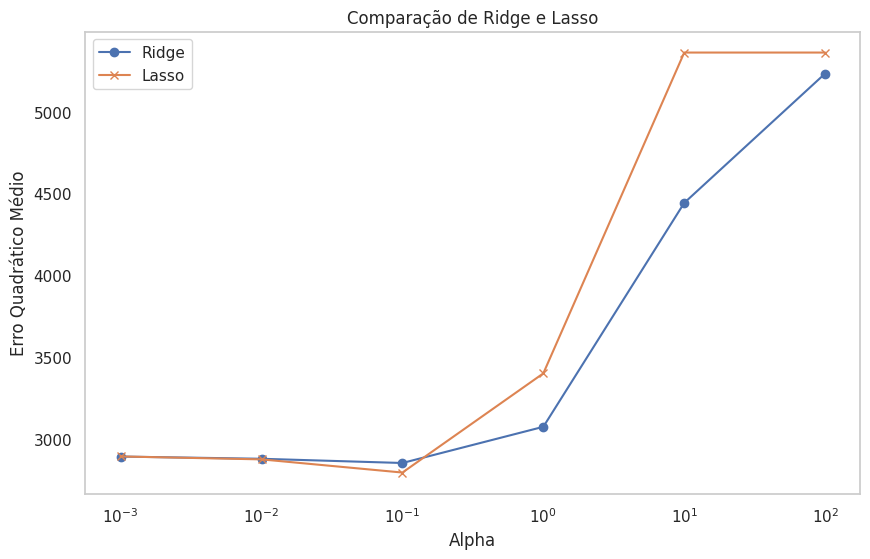

In [36]:
# Valores para ver onde o MSE é minimizado

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

erro_ridge = []
erro_lasso = []

# Treinar modelos

for alpha in alphas:

  # Ridge
  modelo_ridge = Ridge(alpha=alpha)
  modelo_ridge.fit(X_train, y_train)
  pred_ridge = modelo_ridge.predict(X_test)

  mse_ridge = mean_squared_error(y_test, pred_ridge)
  erro_ridge.append(mse_ridge)

  # Lasso
  modelo_lasso = Lasso(alpha=alpha)
  modelo_lasso.fit(X_train, y_train)
  pred_lasso = modelo_lasso.predict(X_test)

  mse_lasso = mean_squared_error(y_test, pred_lasso)
  erro_lasso.append(mse_lasso)

plt.figure(figsize=(10, 6))
plt.plot(
    alphas,
    erro_ridge,
    label='Ridge',
    marker='o'
)
plt.plot(
    alphas,
    erro_lasso,
    label='Lasso',
    marker='x'
)

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Erro Quadrático Médio')
plt.title('Comparação de Ridge e Lasso')
plt.legend()
plt.grid()
plt.show()

Comparando Erro de Treino e Erro de Teste para Diferentes Graus Polinomiais:

Grau 1:
  MSE Treino: 2868.5497
  R² Treino: 0.5279
  MSE Teste: 2900.1936
  R² Teste: 0.4526

Grau 2:
  MSE Treino: 2393.1386
  R² Treino: 0.6062
  MSE Teste: 3096.0283
  R² Teste: 0.4156

Grau 3:
  MSE Treino: 745.6184
  R² Treino: 0.8773
  MSE Teste: 82446.0487
  R² Teste: -14.5613

Grau 4:
  MSE Treino: 0.0000
  R² Treino: 1.0000
  MSE Teste: 146484.2453
  R² Teste: -26.6482

Grau 5:
  MSE Treino: 0.0000
  R² Treino: 1.0000
  MSE Teste: 167972.1658
  R² Teste: -30.7039

Grau 6:
  MSE Treino: 0.0000
  R² Treino: 1.0000
  MSE Teste: 334595.0348
  R² Teste: -62.1532



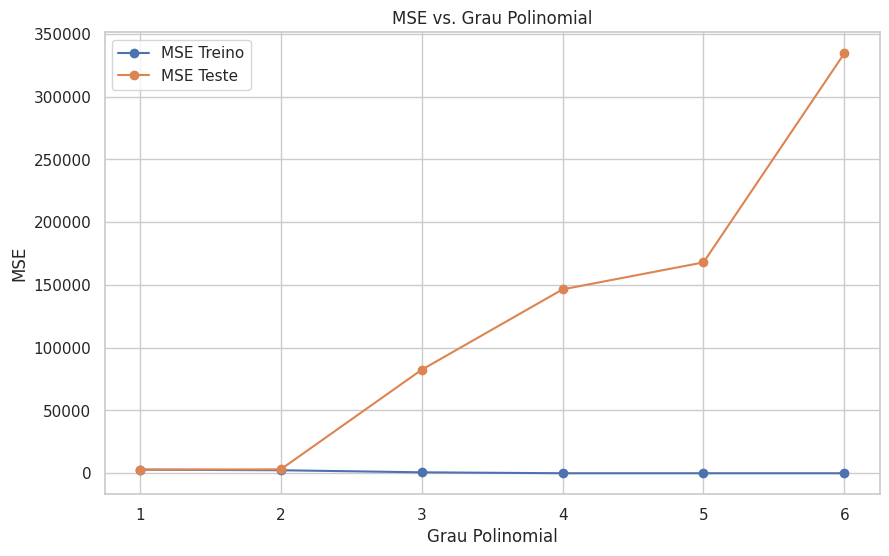

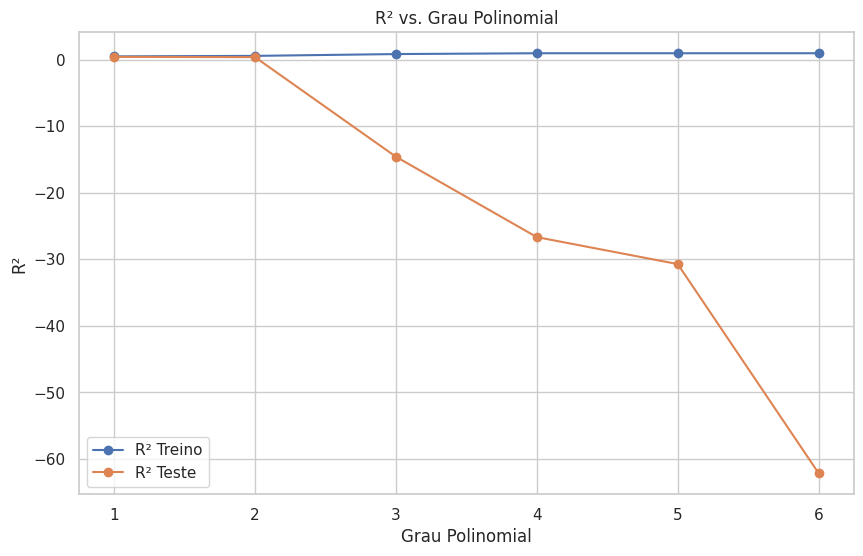

In [37]:

'''
Define os graus polinomiais a serem testados
Grau 1 equivale à regressão linear simples (sem termos polinomiais extras)
Aumentar o grau adiciona termos polinomiais e de interação. Há de se haver cuidado com graus muito altos
em datasets com muitas features, pois o número de features geradas pode explodir.
Neste caso, vemos que para grau >= 3 o modelo começa a sofrer overfitting.
'''

graus = [1, 2, 3, 4, 5, 6] # Você pode ajustar este intervalo

mse_treino_polinomial = []
mse_teste_polinomial = []
r2_treino_polinomial = []
r2_teste_polinomial = []

print("Comparando Erro de Treino e Erro de Teste para Diferentes Graus Polinomiais:\n")

for grau in graus:
    # Cria um pipeline para: 1. Escalar os dados; 2. Gerar features polinomiais; 3. Aplicar Regressão Linear
    # Escalar antes de gerar features polinomiais é importante para evitar que features com escalas maiores
    # dominem os termos polinomiais e os coeficientes do modelo linear.
    model_pipeline = make_pipeline(
        StandardScaler(), # Padroniza os dados (média 0, desvio padrão 1)
        PolynomialFeatures(degree=grau), # Gera features polinomiais e de interação
        LinearRegression() # Ajusta o modelo de Regressão Linear
    )

    # Ajusta o pipeline aos dados de treino
    model_pipeline.fit(X_train, y_train)

    # Faz previsões nos conjuntos de treino e teste
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    # Calcula as métricas de desempenho
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Armazena os resultados
    mse_treino_polinomial.append(mse_train)
    mse_teste_polinomial.append(mse_test)
    r2_treino_polinomial.append(r2_train)
    r2_teste_polinomial.append(r2_test)

    # Imprime os resultados para o grau atual
    print(f'Grau {grau}:')
    print(f'  MSE Treino: {mse_train:.4f}')
    print(f'  R² Treino: {r2_train:.4f}')
    print(f'  MSE Teste: {mse_test:.4f}')
    print(f'  R² Teste: {r2_test:.4f}\n')

# --- Início das correções e novas visualizações ---

# Plotagem dos resultados de MSE vs. Grau Polinomial
# Este gráfico mostra como o Mean Squared Error (MSE) varia com o grau do polinômio.
# Uma grande diferença entre o MSE de treino e de teste em graus mais altos indica overfitting.
plt.figure(figsize=(10, 6))
plt.plot(graus, mse_treino_polinomial, label='MSE Treino', marker='o')
plt.plot(graus, mse_teste_polinomial, label='MSE Teste', marker='o')
plt.title('MSE vs. Grau Polinomial')
plt.xlabel('Grau Polinomial')
plt.ylabel('MSE')
plt.xticks(graus)
plt.legend()
plt.grid(True)
plt.show()

# Plotagem dos resultados de R² vs. Grau Polinomial
# Este gráfico ilustra como o R-quadrado (R²) varia com o grau do polinômio.
# Um R² alto no treino e baixo (ou negativo) no teste para graus mais altos é um forte indicativo de overfitting.
plt.figure(figsize=(10, 6))
plt.plot(graus, r2_treino_polinomial, label='R² Treino', marker='o')
plt.plot(graus, r2_teste_polinomial, label='R² Teste', marker='o')
plt.title('R² vs. Grau Polinomial')
plt.xlabel('Grau Polinomial')
plt.ylabel('R²')
plt.xticks(graus)
plt.legend()
plt.grid(True)
plt.show()

# --- Fim das correções e novas visualizações ---

Decision Tree:
MAE: 43.4187
MSE: 2972.5166
RMSE: 54.5208
R²: 0.439


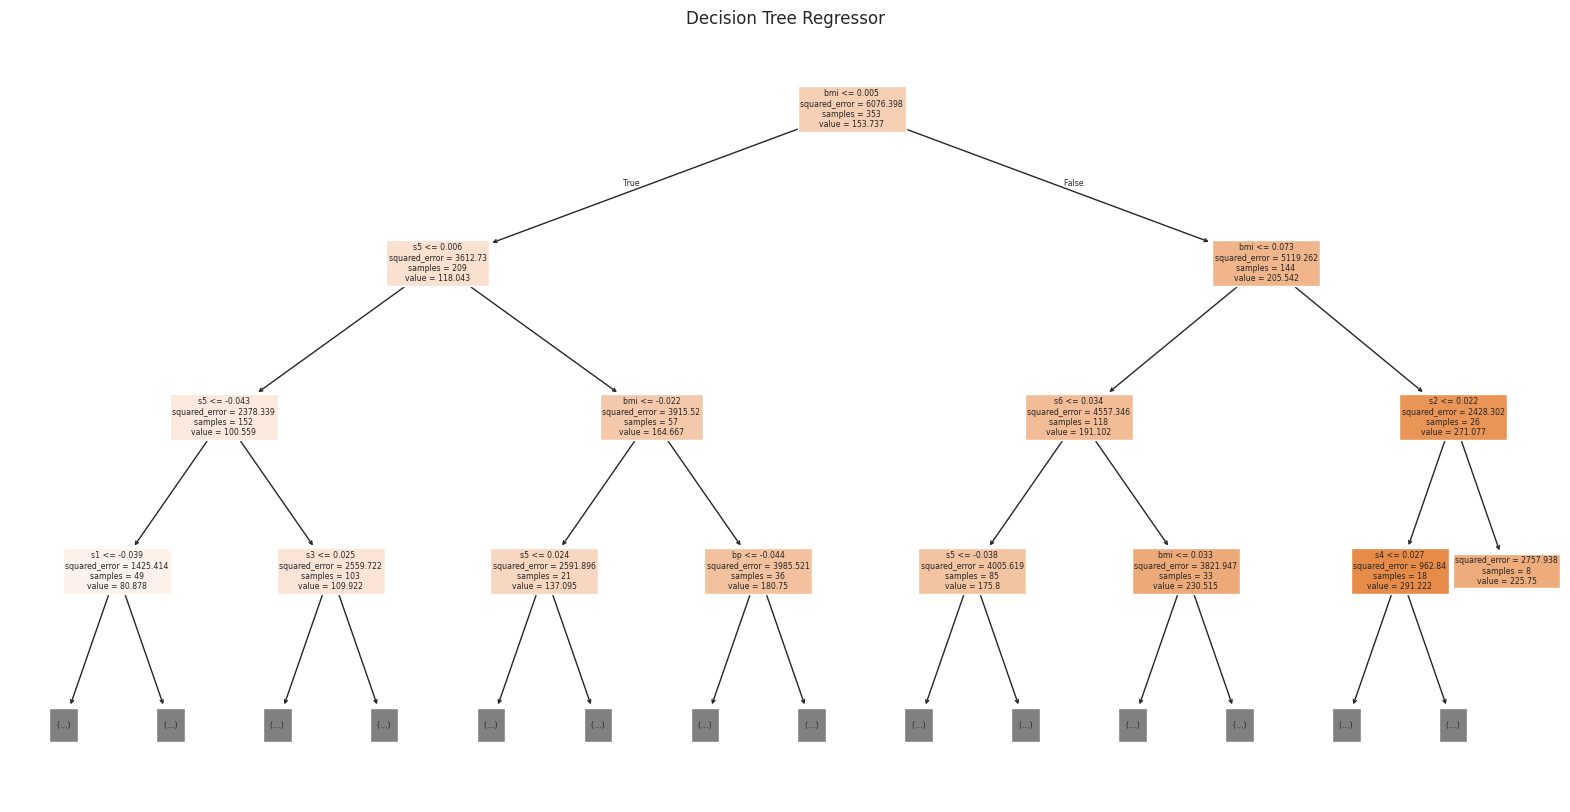

In [38]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, ConfusionMatrixDisplay
import math
'''
 Criando o modelo
 max_depth: profundidade máxima da árvore. Controla o quão profunda a árvore pode ser.
            Valores menores ajudam a prevenir o overfitting.
 min_samples_split: O número mínimo de amostras que um nó deve ter para ser dividido.
                    Se um nó tiver menos amostras que isso, ele não será dividido.
 min_samples_leaf: O número mínimo de amostras que um nó folha (terminal) deve ter.
                   Garate que cada "resposta" da árvore é baseada em um número mínimo de observações.
'''
modelo_arvore = DecisionTreeRegressor(
    max_depth=5, # profundidade máxima de 5
    min_samples_split=10, # mínimo de 10 amostras para dividir um nó
    min_samples_leaf=5, # mínimo de 5 amostras em um nó folha
    random_state=42
)

# Treinamento do modelo
modelo_arvore.fit(X_train, y_train)

# Previsões
pred_arvore = modelo_arvore.predict(X_test)

# Métricas
mae_arvore = mean_absolute_error(y_test, pred_arvore)
mse_arvore = mean_squared_error(y_test, pred_arvore)
rmse_arvore = math.sqrt(mse_arvore)
r2_arvore = r2_score(y_test, pred_arvore)

# Só se usa se for problema de classificação: accuracy_tree = accuracy_score(y_test, pred_arvore ; print(f"Acurácia Decision Tree: {accuracy_tree}"))

print("Decision Tree:")
print("MAE:", round(mae_arvore, 4))
print("MSE:", round(mse_arvore, 4))
print("RMSE:", round(rmse_arvore, 4))
print("R²:", round(r2_arvore, 4))

'''
# A matriz de confusão e a acurácia são para problemas de classificação, não regressão.
ConfusionMatrixDisplay.from_predictions(y_test, pred_arvore, display_labels=diabetes.target_names)
plt.title("Matriz de confusão Decision Tree")
plt.show()
'''

# Gráfico da árvore de decisão
plt.figure(figsize=(20, 10))

plot_tree(
    modelo_arvore,
    feature_names=X.columns,
    filled=True,
    max_depth=3
)

plt.title("Decision Tree Regressor")
plt.show()

In [39]:
modelo_floresta = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

modelo_floresta.fit(X_train, y_train)

pred_floresta = modelo_floresta.predict(X_test)

mae_floresta = mean_absolute_error(y_test, pred_floresta)
mse_floresta = mean_squared_error(y_test, pred_floresta)
rmse_floresta = math.sqrt(mse_floresta)
r2_floresta = r2_score(y_test, pred_floresta)

print("Random Forest:")
print("MAE:", round(mae_floresta, 4))
print("MSE:", round(mse_floresta, 4))
print("RMSE:", round(rmse_floresta, 4))
print("R²:", round(r2_floresta, 6))

Random Forest:
MAE: 43.8428
MSE: 2869.0728
RMSE: 53.5637
R²: 0.458477


,0
bmi,0.439514
s5,0.276226
bp,0.075371
s6,0.055732
s2,0.036683
s3,0.033930
age,0.029770
s1,0.028895
s4,0.017528
sex,0.006349


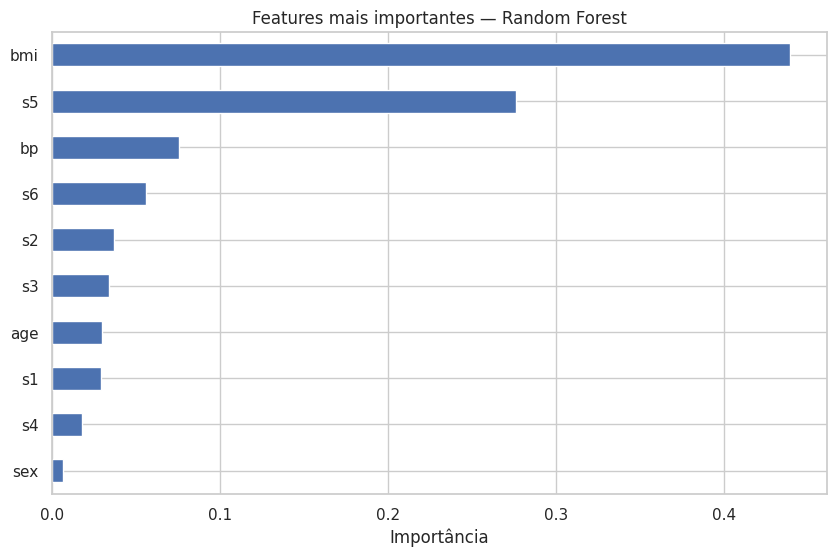

In [41]:
# Importância das features

importancias = pd.Series(
    modelo_floresta.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importancias)

plt.figure(figsize=(10, 6))
importancias.head(10).sort_values().plot(kind="barh")
plt.title("Features mais importantes — Random Forest")
plt.xlabel("Importância")
plt.show()